In [ ]:
import numpy as np
import struct
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation


✅ 数据开始于第 15 行
✅ Header info:
Timesteps                : 2048
Temporal Stepwidth       : 0.0001 s
Points per SideY         : 128
Spatial StepwidthY       : 0.023622 m
Points per SideZ         : 128
Spatial StepwidthZ       : 0.023622 m
Hub Height               : 0.254 m
Mean Wind Speed at Hub   : 10 m/s
Heigth of lowest Point   : -1.246 m
✅ 风场形状: (2048, 128, 128, 3) (time, y, z, components)


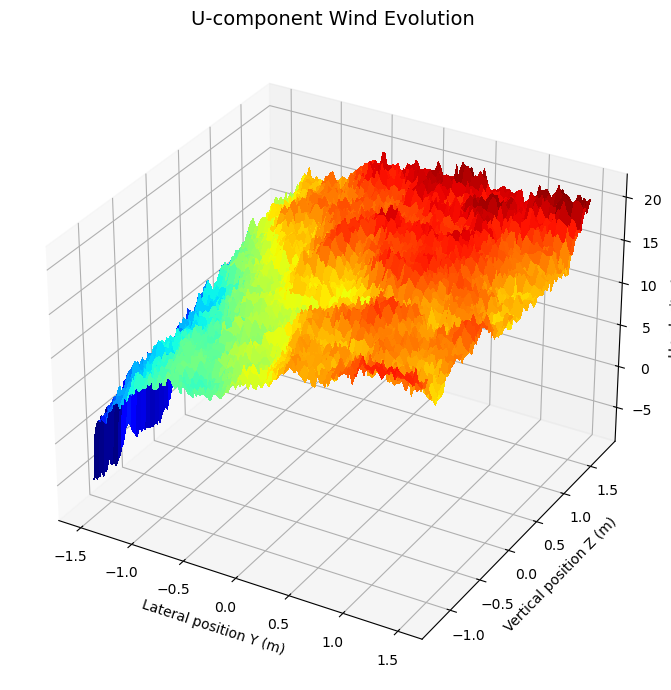

d:\ProgramData\GYwindows\anaconda3\envs\Project_propeller\lib\site-packages\matplotlib\animation.py:884: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(



✅ 数据开始于第 15 行
✅ Header info:
Timesteps                : 2048
Temporal Stepwidth       : 0.0001 s
Points per SideY         : 128
Spatial StepwidthY       : 0.023622 m
Points per SideZ         : 128
Spatial StepwidthZ       : 0.023622 m
Hub Height               : 0.254 m
Mean Wind Speed at Hub   : 10 m/s
Heigth of lowest Point   : -1.246 m
✅ 风场形状: (2048, 128, 128, 3) (time, y, z, components)


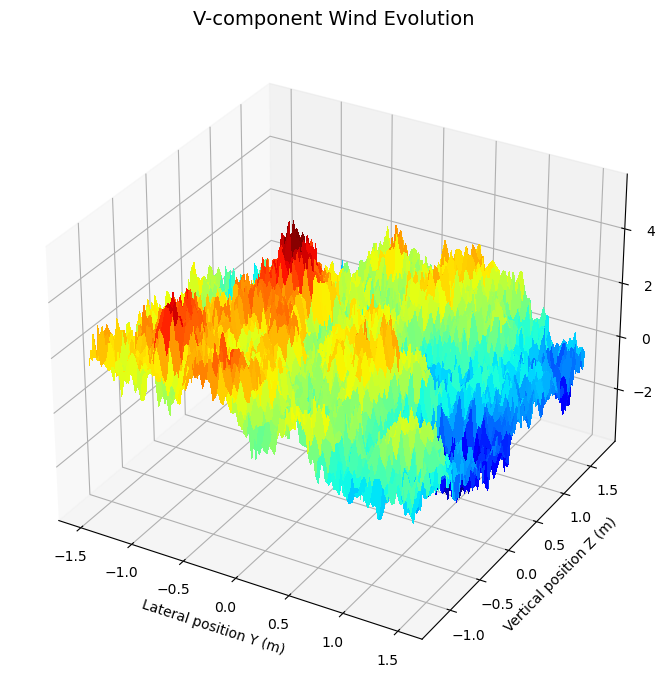


✅ 数据开始于第 15 行
✅ Header info:
Timesteps                : 2048
Temporal Stepwidth       : 0.0001 s
Points per SideY         : 128
Spatial StepwidthY       : 0.023622 m
Points per SideZ         : 128
Spatial StepwidthZ       : 0.023622 m
Hub Height               : 0.254 m
Mean Wind Speed at Hub   : 10 m/s
Heigth of lowest Point   : -1.246 m
✅ 风场形状: (2048, 128, 128, 3) (time, y, z, components)


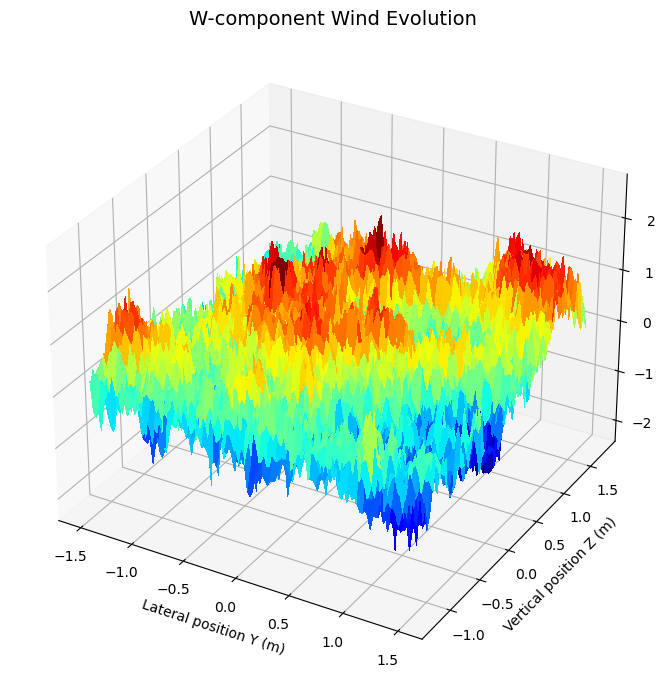

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation

# =====================================================
# 1️⃣ 读取 QBlade ASCII 风场文件
# =====================================================
def read_qblade_ascii_windfield(filename):
    header = {}
    data_start = 0
    # 读取文件并识别头部与数值起始行
    with open(filename, 'r') as f:
        lines = f.readlines()
    for i, line in enumerate(lines):
        if line.startswith('#'):
            parts = line.strip('# \n').split(':')
            if len(parts) == 2:
                header[parts[0].strip()] = parts[1].strip()
        else:
            parts = line.strip().split()
            if len(parts) > 2:
                try:
                    float(parts[0])
                    data_start = i
                    break
                except ValueError:
                    continue

    print(f"\n✅ 数据开始于第 {data_start} 行")
    print("✅ Header info:")
    for k, v in header.items():
        print(f"{k:25s}: {v}")

    # 从 header 获取关键参数
    timesteps = int(header.get('Timesteps', 0))
    ny = int(header.get('Points per SideY', 0))
    nz = int(header.get('Points per SideZ', 0))
    dt = float(header.get('Temporal Stepwidth', '0').split()[0])
    dy = float(header.get('Spatial StepwidthY', '0').split()[0])
    dz = float(header.get('Spatial StepwidthZ', '0').split()[0])
    hub_height = float(header.get('Hub Height', '0').split()[0])

    # 读取主数据
    arr = np.loadtxt(filename, skiprows=data_start)
    expected_size = timesteps * ny * nz * 3
    if arr.size != expected_size:
        raise ValueError(f"❌ 文件大小不匹配：读取 {arr.size}，期望 {expected_size}")

    # reshape 成四维数组
    arr = arr.reshape(timesteps, ny, nz, 3)
    print(f"✅ 风场形状: {arr.shape} (time, y, z, components)")

    return arr, dict(dt=dt, dy=dy, dz=dz, ny=ny, nz=nz, hub_height=hub_height)


# =====================================================
# 2️⃣ 动画函数：显示风速分量随时间演化
# =====================================================
def animate_wind_component(filename, comp='U', step_stride=10, save=False):
    """
    comp: 'U', 'V', 'W'
    step_stride: 每隔多少帧取一帧
    save: 是否保存为 mp4
    """
    arr, info = read_qblade_ascii_windfield(filename)
    dt, ny, nz = info['dt'], info['ny'], info['nz']
    y = np.linspace(-info['dy']*(ny-1)/2, info['dy']*(ny-1)/2, ny)
    z = np.linspace(info['hub_height']-info['dz']*(nz-1)/2,
                    info['hub_height']+info['dz']*(nz-1)/2, nz)

    comp_idx = {'U': 0, 'V': 1, 'W': 2}[comp.upper()]
    field = arr[:, :, :, comp_idx]
    nframes = field.shape[0] // step_stride

    # 初始化图像
    fig = plt.figure(figsize=(9,7))
    ax = fig.add_subplot(111, projection='3d')
    Y, Z = np.meshgrid(y, z)
    surf = [ax.plot_surface(Y, Z, field[0].T, cmap='jet', linewidth=0, antialiased=False)]
    ax.set_zlim(np.min(field), np.max(field))
    ax.set_xlabel('Lateral position Y (m)')
    ax.set_ylabel('Vertical position Z (m)')
    ax.set_zlabel(f'{comp}-velocity (m/s)')
    ax.set_title(f'{comp}-component Wind Evolution', fontsize=14)

    # 更新函数
    def update(frame):
        ax.collections.clear()
        surf[0] = ax.plot_surface(Y, Z, field[frame*step_stride].T, cmap='jet', linewidth=0, antialiased=False)
        ax.set_title(f'{comp}-component | Time step = {frame*step_stride}', fontsize=13)
        return surf

    ani = FuncAnimation(fig, update, frames=nframes, interval=80, blit=False)
    plt.tight_layout()

    if save:
        fname = f'{comp}_windfield.mp4'
        ani.save(fname, fps=15, dpi=180)
        print(f"🎬 已保存动画到: {fname}")
    else:
        plt.show()


# =====================================================
# 3️⃣ 主程序：分别生成 U/V/W 三个动画
# =====================================================
filename = "./UAV_urban_pro.txt"

animate_wind_component(filename, comp='U', step_stride=10)
animate_wind_component(filename, comp='V', step_stride=10)
animate_wind_component(filename, comp='W', step_stride=10)
